# 04E — Smoothed institutional and text ensemble

04D 显示大选后早期与晚期存在明显分布变化：Green 和 Liberal Democrat 的支持率下降，议案从 amendment 转向 proposed clause 和其他法案阶段。直接提高近期样本权重会过拟合。

本 Notebook 固定比较：

1. 历史 Hybrid 文本模型；
2. 加入早期大选后数据的 Hybrid 文本模型；
3. 近期政党支持率基线；
4. 分层平滑的制度概率；
5. 预先固定的 `50% 文本 + 50% 制度概率` 集成。

制度层级使用较粗的：

```text
role × government backing
→ role × government backing × motion family
→ party × role × government backing × motion family
```

不会使用稀疏的精确 `motion_type × policy_domain` 组合作为主要概率，以免记忆少量样本。

In [1]:
# 导入本 Notebook 需要的库。
from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET = 'target_binary_support'
TEXT_COLUMN = 'model_text'
ELECTION_TRANSITION_DATE = pd.Timestamp('2024-07-05')

# 时间校验通过前保持 False。
RUN_FINAL_TEST = False

# 固定使用 04C 的模型和阈值设置。
MODEL_C = 0.5
CLASSIFICATION_THRESHOLD = 0.50

# 制度概率的平滑强度越大，少量近期样本对概率的影响越小。
ROLE_SMOOTHING = 30.0
ROLE_FAMILY_SMOOTHING = 20.0
PARTY_ROLE_FAMILY_SMOOTHING = 15.0
RECENT_PARTY_SMOOTHING = 20.0
RECENT_ROLE_SMOOTHING = 12.0
RECENT_EXACT_SMOOTHING = 8.0
MIN_RECENT_EXACT_ROWS = 3
MIN_RECENT_ROLE_ROWS = 3

# Primary ensemble 的权重在查看 temporal holdout 前固定。
PRIMARY_TEXT_WEIGHT = 0.50

MIN_TEMPORAL_MACRO_F1 = 0.65
MIN_TEMPORAL_WORST_PARTY_MACRO_F1 = 0.55
MIN_TEMPORAL_ROWS_PER_PARTY = 15

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'processed' / 'model_v2'
OUTPUT_DIR = DATA_DIR / 'smoothed_ensemble'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'model_train_v2.csv'
VALIDATION_PATH = DATA_DIR / 'model_validation_v2.csv'
TEST_PATH = DATA_DIR / 'model_test_v2.csv'

print('Primary text weight:', PRIMARY_TEXT_WEIGHT)
print('RUN_FINAL_TEST:', RUN_FINAL_TEST)

Primary text weight: 0.5
RUN_FINAL_TEST: False


## 1. Load data and create model features

In [2]:
# 读取三个原始切分；默认不显示 Test 标签统计。
historical_train = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
validation_2024 = pd.read_csv(VALIDATION_PATH).reset_index(drop=True)
test = pd.read_csv(TEST_PATH).reset_index(drop=True)

for frame in (historical_train, validation_2024, test):
    frame[TARGET] = frame[TARGET].astype(int)
    frame[TEXT_COLUMN] = frame[TEXT_COLUMN].fillna('').astype(str)
    frame['motion_date'] = pd.to_datetime(frame['motion_date'])

# 检查原始 Train、Validation 和 Test 没有 division 重叠。
assert not set(historical_train['division_key']) & set(validation_2024['division_key'])
assert not set(historical_train['division_key']) & set(test['division_key'])
assert not set(validation_2024['division_key']) & set(test['division_key'])


def add_model_features(frame):
    # 把政府背书状态转为 government_backed、not_government_backed、unknown。
    result = frame.copy()
    known = result['government_backing_known'].fillna(0).astype(int).eq(1)
    backed = result['final_object_government_backed'].fillna(0).astype(int).eq(1)
    result['government_backing_status'] = np.select(
        [~known, backed],
        ['unknown', 'government_backed'],
        default='not_government_backed',
    )
    result['role_backing_interaction'] = (
        result['party_role'].fillna('unknown').astype(str)
        + '__'
        + result['government_backing_status'].astype(str)
    )
    return result


historical_train = add_model_features(historical_train)
validation_2024 = add_model_features(validation_2024)
test = add_model_features(test)

print('Historical rows:', len(historical_train))
print('2024 validation rows:', len(validation_2024))

Historical rows: 2822
2024 validation rows: 570


## 2. Split post-election data by whole dates

04D 的切分在 `2024-11-06` 同一天两侧都有 division。本次先按唯一日期排序，再把前半日期全部用于 adaptation、后半日期全部用于 temporal holdout，确保同一天不会跨边界。

In [3]:
pre_election_2024 = validation_2024[
    validation_2024['motion_date'] < ELECTION_TRANSITION_DATE
].copy()
post_election_2024 = validation_2024[
    validation_2024['motion_date'] >= ELECTION_TRANSITION_DATE
].copy()

# 使用唯一日期切分，确保同一天的所有 division 在同一侧。
post_dates = np.array(sorted(post_election_2024['motion_date'].dt.normalize().unique()))
assert len(post_dates) >= 6, '大选后的唯一日期太少，无法进行时间切分。'

adaptation_date_count = len(post_dates) // 2
adaptation_dates = set(post_dates[:adaptation_date_count])
holdout_dates = set(post_dates[adaptation_date_count:])

normalised_dates = post_election_2024['motion_date'].dt.normalize()
adaptation_2024 = post_election_2024[
    normalised_dates.isin(adaptation_dates)
].copy()
temporal_holdout = post_election_2024[
    normalised_dates.isin(holdout_dates)
].copy()

assert not adaptation_dates & holdout_dates
assert adaptation_2024['motion_date'].max().normalize() < temporal_holdout[
    'motion_date'
].min().normalize()
assert not set(adaptation_2024['division_key']) & set(
    temporal_holdout['division_key']
)

split_overview = pd.DataFrame({
    'rows': [
        len(historical_train),
        len(pre_election_2024),
        len(adaptation_2024),
        len(temporal_holdout),
    ],
    'divisions': [
        historical_train['division_key'].nunique(),
        pre_election_2024['division_key'].nunique(),
        adaptation_2024['division_key'].nunique(),
        temporal_holdout['division_key'].nunique(),
    ],
    'unique_dates': [
        historical_train['motion_date'].dt.normalize().nunique(),
        pre_election_2024['motion_date'].dt.normalize().nunique(),
        adaptation_2024['motion_date'].dt.normalize().nunique(),
        temporal_holdout['motion_date'].dt.normalize().nunique(),
    ],
    'start_date': [
        historical_train['motion_date'].min(),
        pre_election_2024['motion_date'].min(),
        adaptation_2024['motion_date'].min(),
        temporal_holdout['motion_date'].min(),
    ],
    'end_date': [
        historical_train['motion_date'].max(),
        pre_election_2024['motion_date'].max(),
        adaptation_2024['motion_date'].max(),
        temporal_holdout['motion_date'].max(),
    ],
    'support_rate': [
        historical_train[TARGET].mean(),
        pre_election_2024[TARGET].mean(),
        adaptation_2024[TARGET].mean(),
        temporal_holdout[TARGET].mean(),
    ],
}, index=[
    'historical_train',
    'pre_election_2024',
    'adaptation_2024',
    'temporal_holdout',
])
display(split_overview.round(3))

holdout_party_rows = temporal_holdout.groupby('party').size()
assert holdout_party_rows.min() >= MIN_TEMPORAL_ROWS_PER_PARTY
display(holdout_party_rows.rename('holdout_rows').to_frame())

,rows,divisions,unique_dates,start_date,end_date,support_rate
historical_train,2822,770,332,2016-01-06,2023-12-13,0.569
pre_election_2024,356,106,34,2024-01-09,2024-05-24,0.607
adaptation_2024,71,23,13,2024-07-22,2024-10-29,0.549
temporal_holdout,143,40,14,2024-11-06,2024-12-17,0.573


,holdout_rows
party,
conservative,37
green,36
labour,40
liberal-democrat,30


## 3. Frozen Hybrid text model

继续使用 04C 胜出的：全局 Word TF-IDF、政党专属 Word TF-IDF 区块和共享扩展结构特征。

In [4]:
EXTENDED_CATEGORICAL = [
    'party',
    'party_role',
    'government_backing_status',
    'role_backing_interaction',
    'party_object_alignment',
    'motion_type',
    'motion_family',
    'policy_domain_primary',
    'policy_domain_confidence',
    'government_party',
    'main_opposition_party',
]

EXTENDED_NUMERIC = [
    'government_backing_known',
    'final_object_government_backed',
    'is_governing_party',
    'is_main_opposition',
    'is_opposition_day',
    'motion_year',
    'motion_month',
    'years_since_2016',
    'total_possible_members',
    'has_legislation_name',
    'bill_link_available',
    'is_amendment',
    'is_new_clause',
    'is_financial_motion',
    'legacy_domain_count',
    'policy_domain_count',
    'is_econ_finance',
    'is_justice_security',
    'is_env_infra',
    'is_social_health',
    'is_national_affairs',
]


def make_word_vectorizer():
    # 使用已经冻结的 Word TF-IDF 参数。
    return TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.98,
        max_features=30000,
        sublinear_tf=True,
    )


def make_structured_transformer():
    # 类别字段 one-hot，数值字段补缺并缩放。
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ])
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('categorical', categorical_pipeline, EXTENDED_CATEGORICAL),
        ('numeric', numeric_pipeline, EXTENDED_NUMERIC),
    ], remainder='drop')


def make_party_text_blocks(text_matrix, parties, party_order):
    # 每一行只激活当前政党的文本区块。
    party_values = pd.Series(parties).astype(str).to_numpy()
    blocks = []
    for party in party_order:
        mask = (party_values == party).astype(float).reshape(-1, 1)
        blocks.append(text_matrix.multiply(mask))
    return hstack(blocks, format='csr')


def fit_hybrid_text_model(development_frame, evaluation_frame):
    # 所有文本和结构转换只在 development 上拟合。
    unique_text = (
        development_frame.drop_duplicates('division_key')[TEXT_COLUMN]
        .fillna('')
        .astype(str)
    )
    party_order = sorted(development_frame['party'].astype(str).unique())

    word_vectorizer = make_word_vectorizer()
    word_vectorizer.fit(unique_text)
    development_word = word_vectorizer.transform(development_frame[TEXT_COLUMN])
    evaluation_word = word_vectorizer.transform(evaluation_frame[TEXT_COLUMN])

    development_party_text = make_party_text_blocks(
        development_word, development_frame['party'], party_order
    )
    evaluation_party_text = make_party_text_blocks(
        evaluation_word, evaluation_frame['party'], party_order
    )

    structured_transformer = make_structured_transformer()
    development_structured = structured_transformer.fit_transform(
        development_frame
    )
    evaluation_structured = structured_transformer.transform(
        evaluation_frame
    )

    development_matrix = hstack([
        development_word,
        development_party_text,
        development_structured,
    ], format='csr')
    evaluation_matrix = hstack([
        evaluation_word,
        evaluation_party_text,
        evaluation_structured,
    ], format='csr')

    classifier = LogisticRegression(
        solver='liblinear',
        penalty='l2',
        C=MODEL_C,
        class_weight='balanced',
        max_iter=2500,
        random_state=RANDOM_STATE,
    )
    classifier.fit(development_matrix, development_frame[TARGET].to_numpy())
    positive_index = list(classifier.classes_).index(1)
    probabilities = classifier.predict_proba(
        evaluation_matrix
    )[:, positive_index]

    fitted = {
        'word': word_vectorizer,
        'structured': structured_transformer,
        'classifier': classifier,
        'party_order': party_order,
    }
    return probabilities, fitted

## 4. Hierarchical smoothed institutional probability

历史概率先在跨政党的制度层级上学习，再逐步加入 motion family 和 party。新政府时期未见过的 `Labour governing` 可以回退到其他执政党的共享规律。

近期 adaptation 只有在组内样本足够时才更新历史概率，并通过伪样本强度进行收缩。

In [5]:
def aggregate_target(frame, keys):
    # 返回每个分组的支持数量和总数量。
    return (
        frame.groupby(keys, dropna=False)[TARGET]
        .agg(target_sum='sum', rows='size')
        .reset_index()
    )


def table_to_dict(table, keys):
    # 把分组表转成 tuple key 字典，便于逐行回退。
    result = {}
    for _, row in table.iterrows():
        key = tuple(row[column] for column in keys)
        result[key] = (float(row['target_sum']), int(row['rows']))
    return result


def fit_historical_tables(historical_reference):
    # 只使用大选前可获得的数据建立制度层级。
    global_rate = float(historical_reference[TARGET].mean())
    role_keys = ['role_backing_interaction']
    role_family_keys = ['role_backing_interaction', 'motion_family']
    party_role_family_keys = [
        'party', 'role_backing_interaction', 'motion_family'
    ]
    return {
        'global_rate': global_rate,
        'role': table_to_dict(
            aggregate_target(historical_reference, role_keys), role_keys
        ),
        'role_family': table_to_dict(
            aggregate_target(historical_reference, role_family_keys),
            role_family_keys,
        ),
        'party_role_family': table_to_dict(
            aggregate_target(historical_reference, party_role_family_keys),
            party_role_family_keys,
        ),
    }


def historical_probability_for_row(row, tables):
    # 从共享角色概率逐层收缩到更具体的 party 组合。
    probability = tables['global_rate']

    role_key = (row['role_backing_interaction'],)
    if role_key in tables['role']:
        target_sum, rows = tables['role'][role_key]
        probability = (
            target_sum + ROLE_SMOOTHING * probability
        ) / (rows + ROLE_SMOOTHING)

    role_family_key = (
        row['role_backing_interaction'], row['motion_family']
    )
    if role_family_key in tables['role_family']:
        target_sum, rows = tables['role_family'][role_family_key]
        probability = (
            target_sum + ROLE_FAMILY_SMOOTHING * probability
        ) / (rows + ROLE_FAMILY_SMOOTHING)

    party_role_family_key = (
        row['party'],
        row['role_backing_interaction'],
        row['motion_family'],
    )
    if party_role_family_key in tables['party_role_family']:
        target_sum, rows = tables['party_role_family'][party_role_family_key]
        probability = (
            target_sum + PARTY_ROLE_FAMILY_SMOOTHING * probability
        ) / (rows + PARTY_ROLE_FAMILY_SMOOTHING)

    return float(probability)


def fit_recent_tables(recent_frame):
    # 近期层级从粗到细；预测时选择最具体且样本足够的一层。
    party_keys = ['party']
    party_role_keys = ['party', 'role_backing_interaction']
    exact_keys = ['party', 'role_backing_interaction', 'motion_family']
    return {
        'party': table_to_dict(
            aggregate_target(recent_frame, party_keys), party_keys
        ),
        'party_role': table_to_dict(
            aggregate_target(recent_frame, party_role_keys), party_role_keys
        ),
        'exact': table_to_dict(
            aggregate_target(recent_frame, exact_keys), exact_keys
        ),
    }


def update_with_recent(row, historical_probability, recent_tables):
    # 默认使用政党层近期概率；有足够样本时再使用更具体层级。
    selected = None
    smoothing = None

    exact_key = (
        row['party'], row['role_backing_interaction'], row['motion_family']
    )
    party_role_key = (row['party'], row['role_backing_interaction'])
    party_key = (row['party'],)

    if (
        exact_key in recent_tables['exact']
        and recent_tables['exact'][exact_key][1] >= MIN_RECENT_EXACT_ROWS
    ):
        selected = recent_tables['exact'][exact_key]
        smoothing = RECENT_EXACT_SMOOTHING
    elif (
        party_role_key in recent_tables['party_role']
        and recent_tables['party_role'][party_role_key][1]
        >= MIN_RECENT_ROLE_ROWS
    ):
        selected = recent_tables['party_role'][party_role_key]
        smoothing = RECENT_ROLE_SMOOTHING
    elif party_key in recent_tables['party']:
        selected = recent_tables['party'][party_key]
        smoothing = RECENT_PARTY_SMOOTHING

    if selected is None:
        return float(historical_probability)

    target_sum, rows = selected
    return float(
        (target_sum + smoothing * historical_probability)
        / (rows + smoothing)
    )


def institutional_probabilities(
    historical_reference,
    recent_adaptation,
    evaluation_frame,
):
    # 先计算历史制度概率，再使用 adaptation 做平滑更新。
    historical_tables = fit_historical_tables(historical_reference)
    recent_tables = fit_recent_tables(recent_adaptation)
    probabilities = []
    historical_only = []

    for _, row in evaluation_frame.iterrows():
        historical_probability = historical_probability_for_row(
            row, historical_tables
        )
        updated_probability = update_with_recent(
            row, historical_probability, recent_tables
        )
        historical_only.append(historical_probability)
        probabilities.append(updated_probability)

    return np.asarray(probabilities), np.asarray(historical_only)

## 5. Evaluation helpers

In [6]:
def safe_roc_auc(y_true, probabilities):
    # 只有一个真实类别时 ROC-AUC 无定义。
    return (
        roc_auc_score(y_true, probabilities)
        if pd.Series(y_true).nunique() == 2
        else np.nan
    )


def evaluate_probabilities(
    y_true,
    probabilities,
    threshold=CLASSIFICATION_THRESHOLD,
):
    # 同时评价分类结果和概率质量。
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_true, predictions),
        'macro_f1': f1_score(
            y_true, predictions, average='macro', zero_division=0
        ),
        'support_precision': precision_score(
            y_true, predictions, zero_division=0
        ),
        'support_recall': recall_score(y_true, predictions, zero_division=0),
        'support_f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': safe_roc_auc(y_true, probabilities),
        'log_loss': log_loss(y_true, probabilities, labels=[0, 1]),
        'brier': brier_score_loss(y_true, probabilities),
        'threshold': threshold,
    }


def subgroup_metrics(frame, probabilities):
    # 分政党检查 temporal holdout。
    work = frame[['party', TARGET]].copy()
    work['probability'] = np.asarray(probabilities)
    work['prediction'] = work['probability'].ge(
        CLASSIFICATION_THRESHOLD
    ).astype(int)
    rows = []
    for party, subset in work.groupby('party'):
        rows.append({
            'party': party,
            'rows': len(subset),
            'support_rate': subset[TARGET].mean(),
            'predicted_support_rate': subset['prediction'].mean(),
            'mean_probability': subset['probability'].mean(),
            'accuracy': accuracy_score(subset[TARGET], subset['prediction']),
            'balanced_accuracy': (
                balanced_accuracy_score(subset[TARGET], subset['prediction'])
                if subset[TARGET].nunique() == 2 else np.nan
            ),
            'macro_f1': (
                f1_score(
                    subset[TARGET], subset['prediction'],
                    average='macro', zero_division=0,
                )
                if subset[TARGET].nunique() == 2 else np.nan
            ),
        })
    return pd.DataFrame(rows).sort_values('macro_f1', na_position='last')


def division_bootstrap_macro_f1(frame, probabilities, iterations=1000):
    # 以 division 为单位重采样，保留议案内四个政党的相关性。
    rng = np.random.default_rng(RANDOM_STATE)
    division_to_indices = {
        key: np.flatnonzero(frame['division_key'].to_numpy() == key)
        for key in frame['division_key'].unique()
    }
    keys = np.array(list(division_to_indices), dtype=object)
    y_true = frame[TARGET].to_numpy()
    predictions = (
        np.asarray(probabilities) >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    scores = []
    for _ in range(iterations):
        sampled_keys = rng.choice(keys, size=len(keys), replace=True)
        sampled_indices = np.concatenate([
            division_to_indices[key] for key in sampled_keys
        ])
        scores.append(f1_score(
            y_true[sampled_indices],
            predictions[sampled_indices],
            average='macro',
            zero_division=0,
        ))
    return {
        'ci_2_5': float(np.quantile(scores, 0.025)),
        'ci_97_5': float(np.quantile(scores, 0.975)),
    }

## 6. Fit text, recent-prior and institutional models

所有概率只使用 temporal holdout 之前的数据生成。Primary ensemble 权重固定为 50/50，不在 holdout 上搜索最佳权重。

In [7]:
historical_reference = pd.concat(
    [historical_train, pre_election_2024], ignore_index=True
)
adapted_development = pd.concat(
    [historical_reference, adaptation_2024], ignore_index=True
)
y_holdout = temporal_holdout[TARGET].to_numpy()

# 历史文本模型不看 adaptation，用于衡量旧环境模型。
started = time.perf_counter()
historical_text_probabilities, historical_text_model = fit_hybrid_text_model(
    historical_reference, temporal_holdout
)
historical_text_seconds = time.perf_counter() - started

# Adapted 文本模型加入早期大选后数据。
started = time.perf_counter()
adapted_text_probabilities, adapted_text_model = fit_hybrid_text_model(
    adapted_development, temporal_holdout
)
adapted_text_seconds = time.perf_counter() - started

# 分层制度概率先从历史规则出发，再被近期数据平滑更新。
institutional_updated_probabilities, institutional_historical_probabilities = (
    institutional_probabilities(
        historical_reference,
        adaptation_2024,
        temporal_holdout,
    )
)

# 近期政党先验使用历史政党率作为伪样本，避免 adaptation 小样本过拟合。
historical_party_rate = historical_reference.groupby('party')[TARGET].mean()
recent_party_stats = adaptation_2024.groupby('party')[TARGET].agg(['sum', 'count'])
recent_party_probability_table = {}
for party in historical_party_rate.index:
    recent_sum = float(recent_party_stats.loc[party, 'sum'])
    recent_count = float(recent_party_stats.loc[party, 'count'])
    prior = float(historical_party_rate.loc[party])
    recent_party_probability_table[party] = (
        recent_sum + RECENT_PARTY_SMOOTHING * prior
    ) / (recent_count + RECENT_PARTY_SMOOTHING)

recent_party_probabilities = (
    temporal_holdout['party']
    .map(recent_party_probability_table)
    .fillna(historical_reference[TARGET].mean())
    .to_numpy()
)

# Primary ensemble 权重提前固定，不根据 holdout 最优结果调整。
primary_ensemble_probabilities = (
    PRIMARY_TEXT_WEIGHT * adapted_text_probabilities
    + (1.0 - PRIMARY_TEXT_WEIGHT) * institutional_updated_probabilities
)

# 额外权重仅用于敏感性分析，不参与本轮验收模型选择。
sensitivity_probabilities = {
    'ensemble_25_text_75_institution': (
        0.25 * adapted_text_probabilities
        + 0.75 * institutional_updated_probabilities
    ),
    'ensemble_75_text_25_institution': (
        0.75 * adapted_text_probabilities
        + 0.25 * institutional_updated_probabilities
    ),
}

probability_sets = {
    'historical_hybrid_text': historical_text_probabilities,
    'adapted_hybrid_text': adapted_text_probabilities,
    'recent_party_prior_smoothed': recent_party_probabilities,
    'historical_institutional_smoothed': institutional_historical_probabilities,
    'updated_institutional_smoothed': institutional_updated_probabilities,
    'primary_ensemble_50_50': primary_ensemble_probabilities,
    **sensitivity_probabilities,
}

comparison_rows = []
for model_name, probabilities in probability_sets.items():
    metrics = evaluate_probabilities(y_holdout, probabilities)
    metrics['model'] = model_name
    comparison_rows.append(metrics)
    print(
        f'{model_name}: macro_f1={metrics["macro_f1"]:.3f}, '
        f'roc_auc={metrics["roc_auc"]:.3f}'
    )

model_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index('model')
    .sort_values('macro_f1', ascending=False)
)
model_comparison.to_csv(
    OUTPUT_DIR / 'smoothed_ensemble_model_comparison.csv'
)
display(model_comparison.round(3))

historical_hybrid_text: macro_f1=0.440, roc_auc=0.494
adapted_hybrid_text: macro_f1=0.452, roc_auc=0.498
recent_party_prior_smoothed: macro_f1=0.594, roc_auc=0.555
historical_institutional_smoothed: macro_f1=0.515, roc_auc=0.587
updated_institutional_smoothed: macro_f1=0.589, roc_auc=0.624
primary_ensemble_50_50: macro_f1=0.564, roc_auc=0.561
ensemble_25_text_75_institution: macro_f1=0.550, roc_auc=0.590
ensemble_75_text_25_institution: macro_f1=0.503, roc_auc=0.540


,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,support_f1,roc_auc,log_loss,brier,threshold
model,,,,,,,,,,
recent_party_prior_smoothed,0.594,0.602,0.594,0.682,0.549,0.608,0.555,0.664,0.236,0.5
updated_institutional_smoothed,0.608,0.589,0.589,0.641,0.720,0.678,0.624,0.681,0.242,0.5
primary_ensemble_50_50,0.566,0.567,0.564,0.639,0.561,0.597,0.561,0.738,0.266,0.5
ensemble_25_text_75_institution,0.566,0.551,0.550,0.614,0.659,0.635,0.590,0.695,0.249,0.5
historical_institutional_smoothed,0.531,0.516,0.515,0.586,0.622,0.604,0.587,0.814,0.284,0.5
ensemble_75_text_25_institution,0.503,0.515,0.503,0.590,0.439,0.503,0.540,0.810,0.294,0.5
adapted_hybrid_text,0.455,0.474,0.452,0.538,0.341,0.418,0.498,0.940,0.332,0.5
historical_hybrid_text,0.441,0.456,0.440,0.518,0.354,0.420,0.494,0.961,0.330,0.5


## 7. Evaluate the predefined 50/50 ensemble

即使其他敏感性权重偶然更高，本轮 Gate 仍只使用预先固定的 `primary_ensemble_50_50`。

In [8]:
primary_model_name = 'primary_ensemble_50_50'
primary_probabilities = probability_sets[primary_model_name]
primary_metrics = evaluate_probabilities(y_holdout, primary_probabilities)
primary_party_metrics = subgroup_metrics(
    temporal_holdout, primary_probabilities
)
bootstrap_interval = division_bootstrap_macro_f1(
    temporal_holdout, primary_probabilities, iterations=1000
)

worst_party_macro_f1 = float(
    primary_party_metrics['macro_f1'].dropna().min()
)
minimum_party_rows = int(primary_party_metrics['rows'].min())

temporal_acceptance_checks = {
    'temporal_macro_f1_gate': (
        primary_metrics['macro_f1'] >= MIN_TEMPORAL_MACRO_F1
    ),
    'temporal_worst_party_gate': (
        worst_party_macro_f1 >= MIN_TEMPORAL_WORST_PARTY_MACRO_F1
    ),
    'minimum_party_rows_gate': (
        minimum_party_rows >= MIN_TEMPORAL_ROWS_PER_PARTY
    ),
}
temporal_validation_passes = all(temporal_acceptance_checks.values())

if temporal_validation_passes:
    next_step = (
        'Smoothed ensemble passes temporal validation. Freeze all settings '
        'before the single final Test run.'
    )
else:
    next_step = (
        'Smoothed ensemble does not pass. Do not run Test; the remaining '
        'problem is not solved by simple historical/recent blending.'
    )

primary_party_metrics.to_csv(
    OUTPUT_DIR / 'primary_ensemble_party_metrics.csv', index=False
)

display(pd.Series({
    'primary_model': primary_model_name,
    'temporal_macro_f1': primary_metrics['macro_f1'],
    'temporal_accuracy': primary_metrics['accuracy'],
    'temporal_roc_auc': primary_metrics['roc_auc'],
    'worst_party_macro_f1': worst_party_macro_f1,
    'bootstrap_ci_2_5': bootstrap_interval['ci_2_5'],
    'bootstrap_ci_97_5': bootstrap_interval['ci_97_5'],
    'passes_all_temporal_gates': temporal_validation_passes,
    'next_step': next_step,
}, name='value').to_frame())
display(primary_party_metrics.round(3))

,value
primary_model,primary_ensemble_50_50
temporal_macro_f1,0.563853
temporal_accuracy,0.566434
temporal_roc_auc,0.560976
worst_party_macro_f1,0.337793
bootstrap_ci_2_5,0.462789
bootstrap_ci_97_5,0.660808
passes_all_temporal_gates,False
next_step,Smoothed ensemble does not pass. Do not run Te...


,party,rows,support_rate,predicted_support_rate,mean_probability,accuracy,balanced_accuracy,macro_f1
1,green,36,0.694,0.583,0.581,0.389,0.331,0.338
3,liberal-democrat,30,0.667,0.600,0.602,0.600,0.575,0.569
2,labour,40,0.625,0.400,0.413,0.625,0.660,0.625
0,conservative,37,0.324,0.459,0.522,0.649,0.653,0.631


## 8. Diagnostics and saved errors

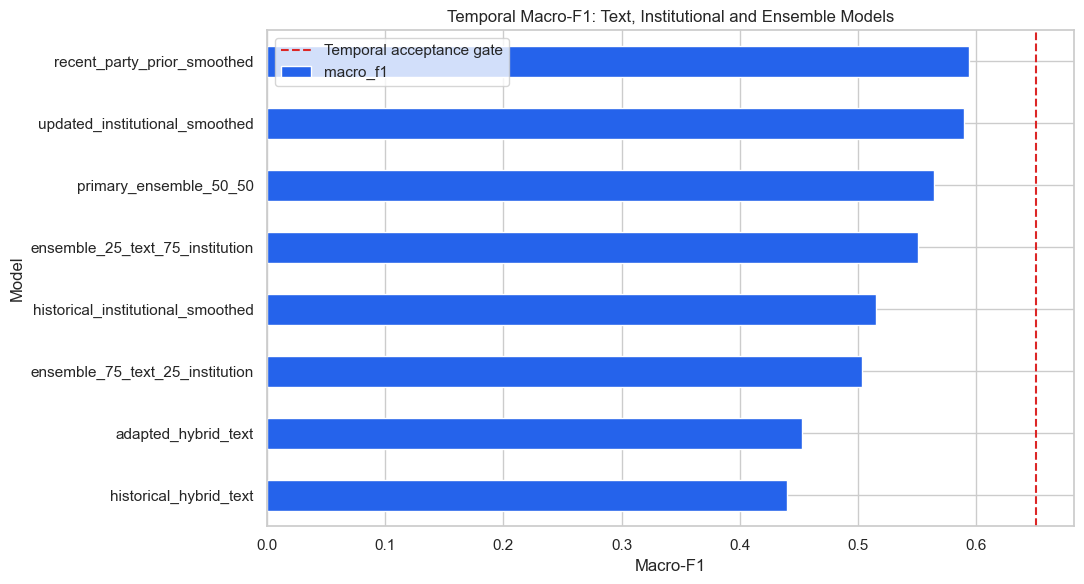

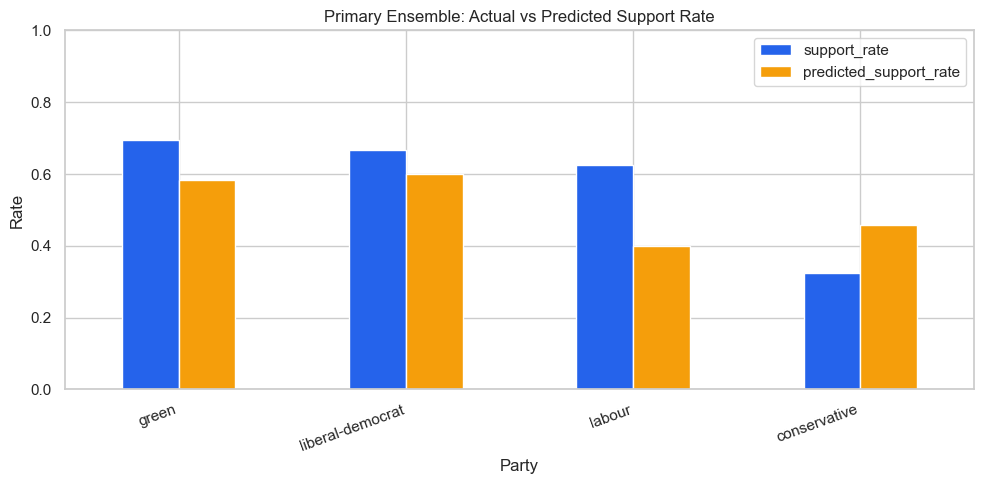

In [9]:
# 比较模型和基线的 temporal Macro-F1。
plot_data = model_comparison.sort_values('macro_f1')
ax = plot_data['macro_f1'].plot(
    kind='barh', figsize=(11, 6), color='#2563EB'
)
ax.axvline(
    MIN_TEMPORAL_MACRO_F1,
    color='#DC2626',
    linestyle='--',
    label='Temporal acceptance gate',
)
ax.set_title('Temporal Macro-F1: Text, Institutional and Ensemble Models')
ax.set_xlabel('Macro-F1')
ax.set_ylabel('Model')
ax.legend()
plt.tight_layout()
plt.show()

# 比较各政党的真实和预测支持率。
rate_plot = primary_party_metrics.set_index('party')[
    ['support_rate', 'predicted_support_rate']
]
ax = rate_plot.plot(kind='bar', figsize=(10, 5), color=['#2563EB', '#F59E0B'])
ax.set_title('Primary Ensemble: Actual vs Predicted Support Rate')
ax.set_xlabel('Party')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# 保存 temporal holdout 逐行结果和错误分组。
primary_predictions = (
    primary_probabilities >= CLASSIFICATION_THRESHOLD
).astype(int)

temporal_predictions = temporal_holdout[[
    'row_id', 'division_key', 'motion_date', 'party',
    'motion_title_clean', 'motion_type', 'motion_family',
    'policy_domain_primary', 'party_role',
    'government_backing_status', 'role_backing_interaction', TARGET,
]].copy()
temporal_predictions['text_probability'] = adapted_text_probabilities
temporal_predictions['institutional_probability'] = (
    institutional_updated_probabilities
)
temporal_predictions['ensemble_probability'] = primary_probabilities
temporal_predictions['predicted_label'] = primary_predictions
temporal_predictions['is_correct'] = temporal_predictions[
    'predicted_label'
].eq(temporal_predictions[TARGET])
temporal_predictions.to_csv(
    OUTPUT_DIR / 'smoothed_ensemble_temporal_predictions.csv', index=False
)

error_summary = (
    temporal_predictions[~temporal_predictions['is_correct']]
    .groupby(
        ['party', 'motion_family', 'government_backing_status'],
        dropna=False,
    )
    .size()
    .rename('errors')
    .reset_index()
    .sort_values('errors', ascending=False)
)
display(error_summary.head(25))

,party,motion_family,government_backing_status,errors
8,green,amendment_or_clause,not_government_backed,6
13,green,other_motion,government_backed,4
0,conservative,amendment_or_clause,government_backed,3
27,liberal-democrat,delegated_legislation,unknown,3
19,labour,delegated_legislation,unknown,3
18,labour,bill_stage,unknown,3
12,green,delegated_legislation,unknown,3
11,green,bill_stage,unknown,3
15,labour,amendment_or_clause,government_backed,3
2,conservative,amendment_or_clause,unknown,3


## 9. Optional single final Test

只有固定的 50/50 ensemble 通过全部时间 Gate 后，才能设置 `RUN_FINAL_TEST=True`。最终文本模型使用 2016–2024 全部数据；制度模型使用大选前历史规律，并用全部大选后 2024 数据更新。

In [11]:
test_metrics = None
test_party_metrics = None

if RUN_FINAL_TEST:
    assert temporal_validation_passes, '时间校验未通过，禁止运行最终 Test。'

    full_2024_post = pd.concat(
        [adaptation_2024, temporal_holdout], ignore_index=True
    )
    final_development = pd.concat(
        [historical_reference, full_2024_post], ignore_index=True
    )

    final_text_probabilities, final_text_model = fit_hybrid_text_model(
        final_development, test
    )
    final_institutional_probabilities, _ = institutional_probabilities(
        historical_reference,
        full_2024_post,
        test,
    )
    final_test_probabilities = (
        PRIMARY_TEXT_WEIGHT * final_text_probabilities
        + (1.0 - PRIMARY_TEXT_WEIGHT) * final_institutional_probabilities
    )

    test_metrics = evaluate_probabilities(
        test[TARGET].to_numpy(), final_test_probabilities
    )
    test_party_metrics = subgroup_metrics(test, final_test_probabilities)

    test_predictions = test[[
        'row_id', 'division_key', 'motion_date', 'party',
        'motion_title_clean', TARGET,
    ]].copy()
    test_predictions['text_probability'] = final_text_probabilities
    test_predictions['institutional_probability'] = (
        final_institutional_probabilities
    )
    test_predictions['ensemble_probability'] = final_test_probabilities
    test_predictions['predicted_label'] = (
        final_test_probabilities >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    test_predictions.to_csv(
        OUTPUT_DIR / 'final_test_predictions.csv', index=False
    )
    test_party_metrics.to_csv(
        OUTPUT_DIR / 'final_test_party_metrics.csv', index=False
    )

    display(pd.Series(test_metrics, name='test').to_frame())
    display(test_party_metrics.round(3))
else:
    print('Test was not run. Keep RUN_FINAL_TEST=False until temporal validation passes.')

Test was not run. Keep RUN_FINAL_TEST=False until temporal validation passes.


## 10. Summary for review

运行完成后，只需要把下面 Cell 的输出发回给我。

In [12]:
summary_lines = [
    '=== SMOOTHED ENSEMBLE SUMMARY FOR REVIEW ===',
    (
        'Adaptation period: '
        f'{adaptation_2024["motion_date"].min().date()} to '
        f'{adaptation_2024["motion_date"].max().date()}'
    ),
    (
        'Temporal holdout period: '
        f'{temporal_holdout["motion_date"].min().date()} to '
        f'{temporal_holdout["motion_date"].max().date()}'
    ),
    f'Adaptation divisions: {adaptation_2024["division_key"].nunique()}',
    f'Temporal holdout divisions: {temporal_holdout["division_key"].nunique()}',
    f'Primary model: {primary_model_name}',
    f'Temporal Macro-F1: {primary_metrics["macro_f1"]:.3f}',
    f'Temporal Accuracy: {primary_metrics["accuracy"]:.3f}',
    f'Temporal ROC-AUC: {primary_metrics["roc_auc"]:.3f}',
    f'Worst-party Macro-F1: {worst_party_macro_f1:.3f}',
    (
        'Division-bootstrap Macro-F1 95% CI: '
        f'[{bootstrap_interval["ci_2_5"]:.3f}, '
        f'{bootstrap_interval["ci_97_5"]:.3f}]'
    ),
    f'Temporal acceptance gates: {temporal_acceptance_checks}',
    f'Next step: {next_step}',
    'Model comparison:',
    model_comparison[['macro_f1', 'accuracy', 'roc_auc', 'brier']]
    .round(3).to_string(),
    'Primary party metrics:',
    primary_party_metrics.round(3).to_string(index=False),
    f'RUN_FINAL_TEST: {RUN_FINAL_TEST}',
    (
        'Test result: NOT RUN'
        if test_metrics is None
        else f'Test Macro-F1: {test_metrics["macro_f1"]:.3f}'
    ),
    '=== END SMOOTHED ENSEMBLE SUMMARY ===',
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / 'smoothed_ensemble_summary.txt', 'w', encoding='utf-8') as file:
    file.write(summary_text)

=== SMOOTHED ENSEMBLE SUMMARY FOR REVIEW ===
Adaptation period: 2024-07-22 to 2024-10-29
Temporal holdout period: 2024-11-06 to 2024-12-17
Adaptation divisions: 23
Temporal holdout divisions: 40
Primary model: primary_ensemble_50_50
Temporal Macro-F1: 0.564
Temporal Accuracy: 0.566
Temporal ROC-AUC: 0.561
Worst-party Macro-F1: 0.338
Division-bootstrap Macro-F1 95% CI: [0.463, 0.661]
Temporal acceptance gates: {'temporal_macro_f1_gate': False, 'temporal_worst_party_gate': False, 'minimum_party_rows_gate': True}
Next step: Smoothed ensemble does not pass. Do not run Test; the remaining problem is not solved by simple historical/recent blending.
Model comparison:
                                   macro_f1  accuracy  roc_auc  brier
model                                                                
recent_party_prior_smoothed           0.594     0.594    0.555  0.236
updated_institutional_smoothed        0.589     0.608    0.624  0.242
primary_ensemble_50_50                0.564     0.5